In [1]:
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import os
import subprocess
import shutil
import plotly.express as px
import sys
sys.path.append('/gpfs/commons/home/mgarbulowski/homic_package/src') 
from homic import file_readers, kraken2, process_data
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt
from itertools import combinations

homic package imported


In [2]:
# define paths
path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes"
db_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/ref_dbs/hs_wgs"

# samples id 
all_samps = ["KP005", "KP012", "KP013", "KP016", "KP024", "KP025", "KP026", "KP027", "KP029","KP033","KP035","KP038","KP040","KP046","KP047","KP048"]

## loading metadata
meta = pd.read_csv("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/metadata_kp.csv")
meta = meta.loc[meta['id'].isin(all_samps)] # keep only the sequenced ones

In [3]:
# saturation curve
## all pairwise combinations
N = len(all_samps)
pairs = list(combinations(range(1, N + 1), 2))

reads_n = []

species_num = []
jk1_all = []
jk2_all = []

for idx, pair in enumerate(pairs):

    # pair 1
    reads_r1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-" + str(pair[0]) + "/" + all_samps[pair[0]-1] + "_S" + str(pair[0]) + "_L001_k2_1.fastq"
    reads_r2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-" + str(pair[0]) + "/" + all_samps[pair[0]-1] + "_S" + str(pair[0]) + "_L001_k2_2.fastq"
    tmp_r1 = file_readers.fastq(reads_r1)
    tmp_r2 = file_readers.fastq(reads_r2)
    reads_n1 = len(tmp_r1[0]) + len(tmp_r2[0])

    # pair 2
    reads_r1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-" + str(pair[1]) + "/" + all_samps[pair[1]-1] + "_S" + str(pair[1]) + "_L001_k2_1.fastq"
    reads_r2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-" + str(pair[1]) + "/" + all_samps[pair[1]-1] + "_S" + str(pair[1]) + "_L001_k2_2.fastq"
    tmp_r1 = file_readers.fastq(reads_r1)
    tmp_r2 = file_readers.fastq(reads_r2)
    reads_n2 = len(tmp_r1[0]) + len(tmp_r2[0])

    reads_n.append(reads_n1 + reads_n2)
    
    path_blast1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/blast_nt_top5/" + all_samps[pair[0]-1] + "_blastn_report.txt"
    path_blast2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/blast_nt_top5/" + all_samps[pair[1]-1] + "_blastn_report.txt"
   
    df1 = process_data.read_n_clean_blastn(path_blast1, top_hits = True, drop_sp = True)
    df2 = process_data.read_n_clean_blastn(path_blast2, top_hits = True, drop_sp = True)

    s1 = set(df1["species"])
    s2 = set(df2["species"])
    df_species = [*s1] + [*s2]

    #s11 = df1["species"]
    #s22 = df2["species"]
    #df_species2 = [*s11] + [*s22]

    species_num.append(len(s1)+len(s2))
    
    jk1 = process_data.chao_idx(df_species) # m = 2, as pairwise 
    jk1_all.append(jk1[0])

    jk2 = process_data.jknife2(df_species, 2)
    jk2_all.append(jk2[0])

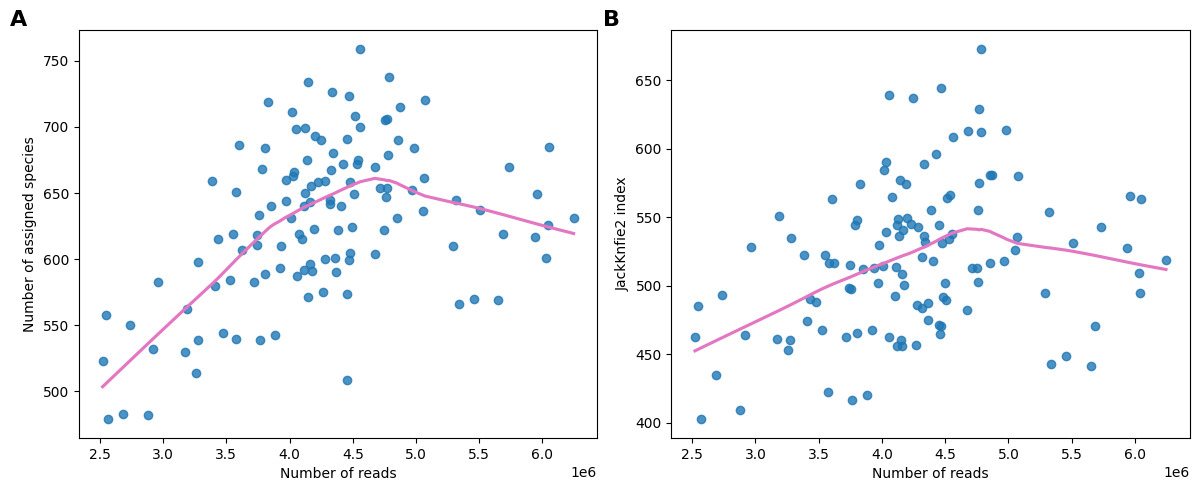

In [4]:
data = {
  "Number of reads": reads_n,
  "Number of assigned species": species_num,
  "Chao2 index": jk1_all,
  "JackKnfie2 index": jk2_all,
}

#load data into a DataFrame object:
df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x="Number of reads", y="Number of assigned species", data=df,
           lowess=True, line_kws={"color": "C6"}, ax=axes[0]);

sns.regplot(x="Number of reads", y="JackKnfie2 index", data=df,
           lowess=True, line_kws={"color": "C6"}, ax=axes[1]);
axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
plt.tight_layout()
plt.show()

fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/figs/saturation_curves_multi_jk1.png", dpi=300, bbox_inches='tight')


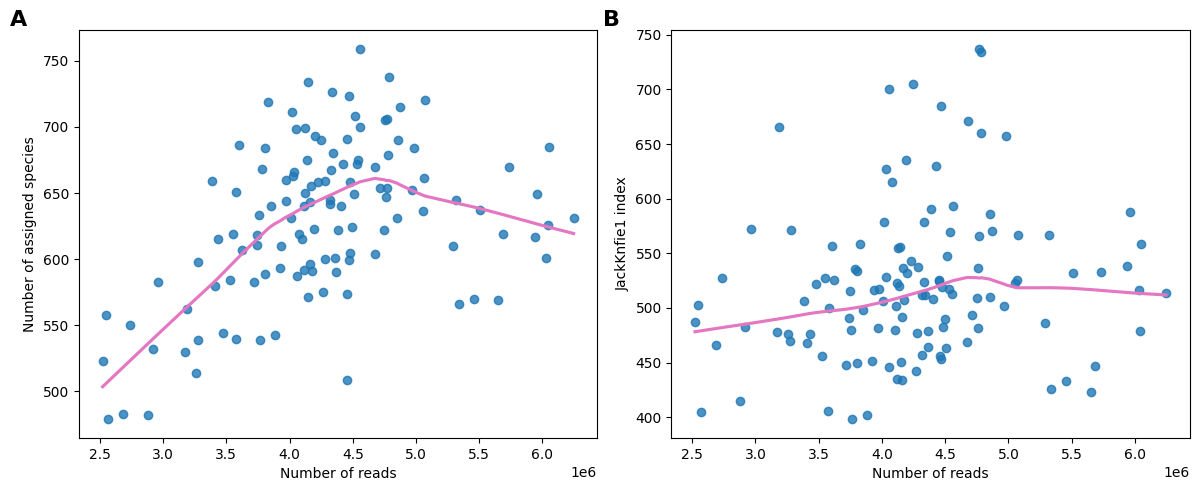

In [5]:
data = {
  "Number of reads": reads_n,
  "Number of assigned species": species_num,
  "JackKnfie1 index": jk1_all,
  "JackKnfie2 index": jk2_all,
}

#load data into a DataFrame object:
df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x="Number of reads", y="Number of assigned species", data=df,
           lowess=True, line_kws={"color": "C6"}, ax=axes[0]);

sns.regplot(x="Number of reads", y="JackKnfie1 index", data=df,
           lowess=True, line_kws={"color": "C6"}, ax=axes[1]);
axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
plt.tight_layout()
plt.show()

fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/figs/saturation_curves_multi_jk2.png", dpi=300, bbox_inches='tight')
